# 🛍️ Customer Segmentation Analysis using Python

## 📌 Project Overview

Customer segmentation is the process of dividing customers into different groups based on their purchasing behavior.

In this project, we analyze the **Online Retail Dataset** using **Python, Pandas, and Exploratory Data Analysis (EDA)** to understand customer purchasing patterns and generate business insights.

---

## 🎯 Objectives

- Clean and preprocess the dataset
- Perform Exploratory Data Analysis (EDA)
- Analyze customer purchasing behavior
- Identify valuable customers
- Generate business insights

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 📚 Import Required Libraries

In this section, we import all the Python libraries required for data manipulation, visualization, and analysis throughout the project.

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings("ignore")

## 📂 Load Dataset

The Online Retail dataset is loaded into a Pandas DataFrame. This dataset contains transactional information such as invoices, products, quantities, prices, customers, and countries.

The dataset will be used throughout this project for customer behavior analysis.

In [82]:
data = pd.read_csv("./Online Retail.csv")

## 🔍 Data Understanding

Before performing any analysis, it is important to understand the dataset.

In this section, we explore:

- Number of rows and columns
- Column names
- Data types
- Sample records
- Overall structure of the dataset

In [83]:
data.shape

(541909, 8)

In [84]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 8:26,3.39,17850.0,United Kingdom


In [85]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [86]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [88]:
data["Quantity"] = data["Quantity"].abs()

In [89]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,11.340487,4.611114,15287.690570
std,217.995482,96.759853,1713.600303
min,1.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [90]:
data["UnitPrice"] = data["UnitPrice"].abs()

In [91]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,11.340487,4.692766,15287.690570
std,217.995482,96.755927,1713.600303
min,1.000000,0.000000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 🧹 Data Cleaning

In this section, the dataset is cleaned by removing invalid records, handling missing values, and preparing the data for analysis.

In [92]:
data = data[data["UnitPrice"] > 0]

In [93]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132605
Country             0
dtype: int64

In [94]:
data.dropna(subset='CustomerID',inplace=True)

In [95]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [96]:
data["Total"] = data["Quantity"] * data["UnitPrice"]

In [97]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/11 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/11 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/11 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/11 12:50,4.15,12680.0,France,16.60


In [98]:
data["Country"].value_counts()

Country
United Kingdom          361854
Germany                   9493
France                    8490
EIRE                      7483
Spain                     2532
Netherlands               2367
Belgium                   2069
Switzerland               1876
Portugal                  1480
Australia                 1256
Norway                    1085
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     250
Unspecified                244
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         57
Lebanon                     45


In [99]:
data["Country"].nunique()

37

## ⚙️ Feature Engineering

In this section, the dataset is transformed by converting data types and creating useful features that will help in customer behavior analysis and time-based insights.

In [100]:
pd.to_datetime("01/12/10 8:26",format="%d/%m/%y %H:%M")

Timestamp('2010-12-01 08:26:00')

In [101]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"],format="%d/%m/%y %H:%M")

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406789 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406789 non-null  object        
 1   StockCode    406789 non-null  object        
 2   Description  406789 non-null  object        
 3   Quantity     406789 non-null  int64         
 4   InvoiceDate  406789 non-null  datetime64[ns]
 5   UnitPrice    406789 non-null  float64       
 6   CustomerID   406789 non-null  float64       
 7   Country      406789 non-null  object        
 8   Total        406789 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


In [103]:
data.set_index('InvoiceDate',inplace=True)

In [104]:
data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Total
InvoiceDate,,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
2011-12-09 12:50:00,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20
2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60
2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60


# 📈 Time Series Analysis

Time series analysis helps understand how customer orders change over time.

In this section, we analyze monthly order trends to identify seasonal patterns, business growth, and purchasing behavior.

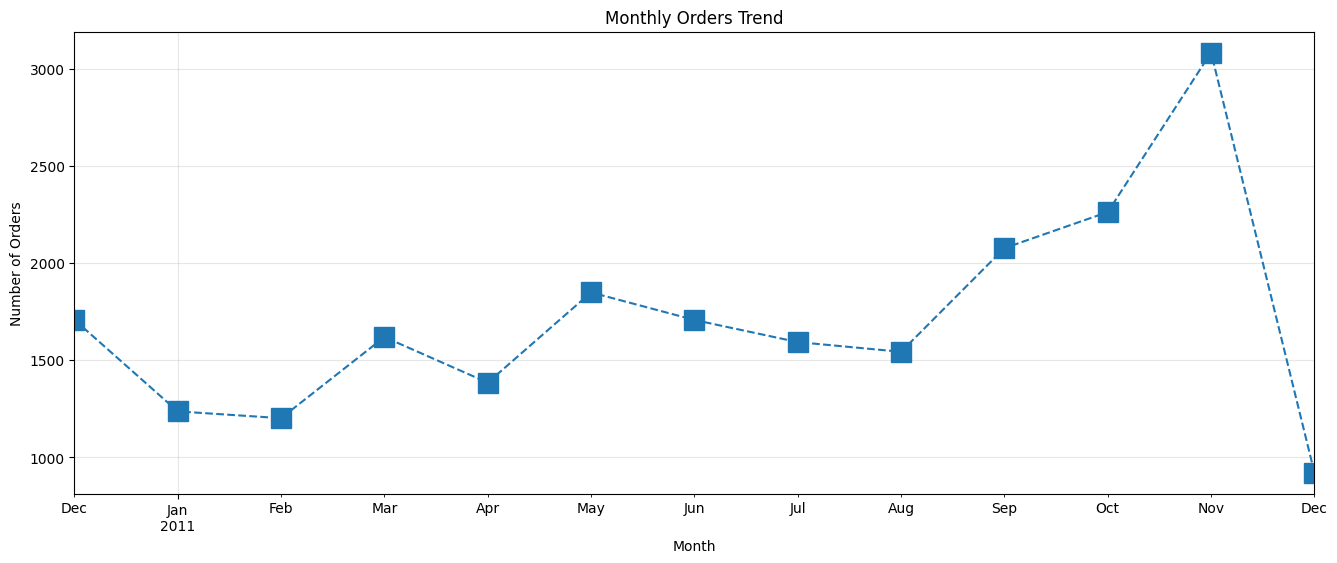

In [105]:
data["InvoiceNo"].resample("MS").nunique().plot(figsize=(16,6),ls="--",marker="s",ms=15)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.3)
plt.show()

In [106]:
data["CustomerID"].resample("MS").nunique()

InvoiceDate
2010-12-01     948
2011-01-01     783
2011-02-01     798
2011-03-01    1020
2011-04-01     899
2011-05-01    1079
2011-06-01    1051
2011-07-01     993
2011-08-01     980
2011-09-01    1302
2011-10-01    1425
2011-11-01    1710
2011-12-01     686
Freq: MS, Name: CustomerID, dtype: int64

In [107]:
data["Total"].resample("MS").sum()

InvoiceDate
2010-12-01     590823.760
2011-01-01     663815.700
2011-02-01     457728.550
2011-03-01     611036.910
2011-04-01     512352.871
2011-05-01     708938.040
2011-06-01     714414.220
2011-07-01     625943.541
2011-08-01     674319.800
2011-09-01     974236.392
2011-10-01    1104033.990
2011-11-01    1191227.020
2011-12-01     693879.200
Freq: MS, Name: Total, dtype: float64

In [108]:
data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Total
InvoiceDate,,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
2011-12-09 12:50:00,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20
2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60
2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60


In [109]:
data.index.max()

Timestamp('2011-12-09 12:50:00')

In [110]:
data=data[data.index < "2011-12-01"]

In [111]:
data.index.max()

Timestamp('2011-11-30 17:42:00')

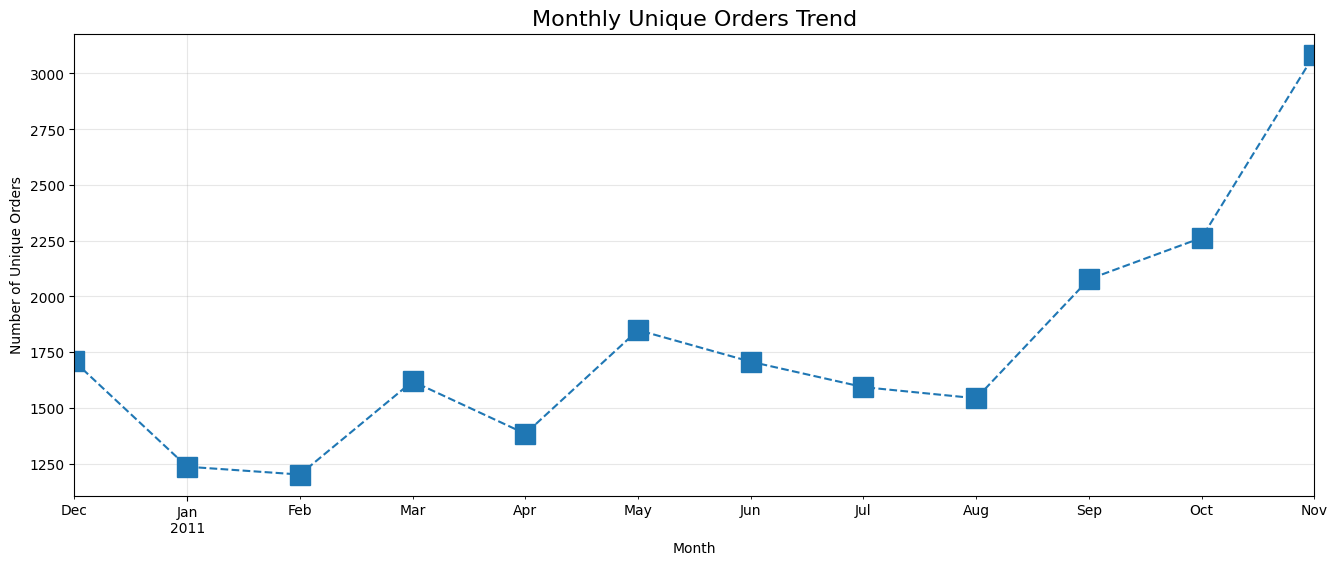

In [118]:
data["InvoiceNo"].resample("MS").nunique().plot(figsize=(16,6),ls="--",marker="s",ms=15)
plt.title("Monthly Unique Orders Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Unique Orders")
plt.grid(alpha=0.3)
plt.show()

### 📌 Business Insight

- This visualization shows the monthly trend of unique customer orders.
- Order volume fluctuates throughout the year, indicating changes in customer purchasing behavior.
- Peak months represent periods of high demand, while lower months indicate reduced sales activity.
- These insights can help businesses improve inventory planning, staffing, and marketing strategies.

In [113]:
data.resample("M").nunique()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Total
InvoiceDate,,,,,,,,
2010-12-31,1708,2422,2429,107,146,948,23,889
2011-01-31,1236,2154,2151,95,139,783,21,846
2011-02-28,1201,2144,2142,91,131,798,24,788
2011-03-31,1619,2244,2250,105,171,1020,23,901
2011-04-30,1384,2228,2236,100,157,899,26,896
2011-05-31,1849,2232,2268,108,182,1079,20,982
2011-06-30,1707,2345,2368,115,178,1051,25,1066
2011-07-31,1593,2370,2392,104,179,993,24,1024
2011-08-31,1543,2369,2399,128,181,980,24,1030


In [114]:
data.index.max()

Timestamp('2011-11-30 17:42:00')

In [115]:
data=data[data.index<"2011-12-01"]

In [116]:
data.index.max()

Timestamp('2011-11-30 17:42:00')

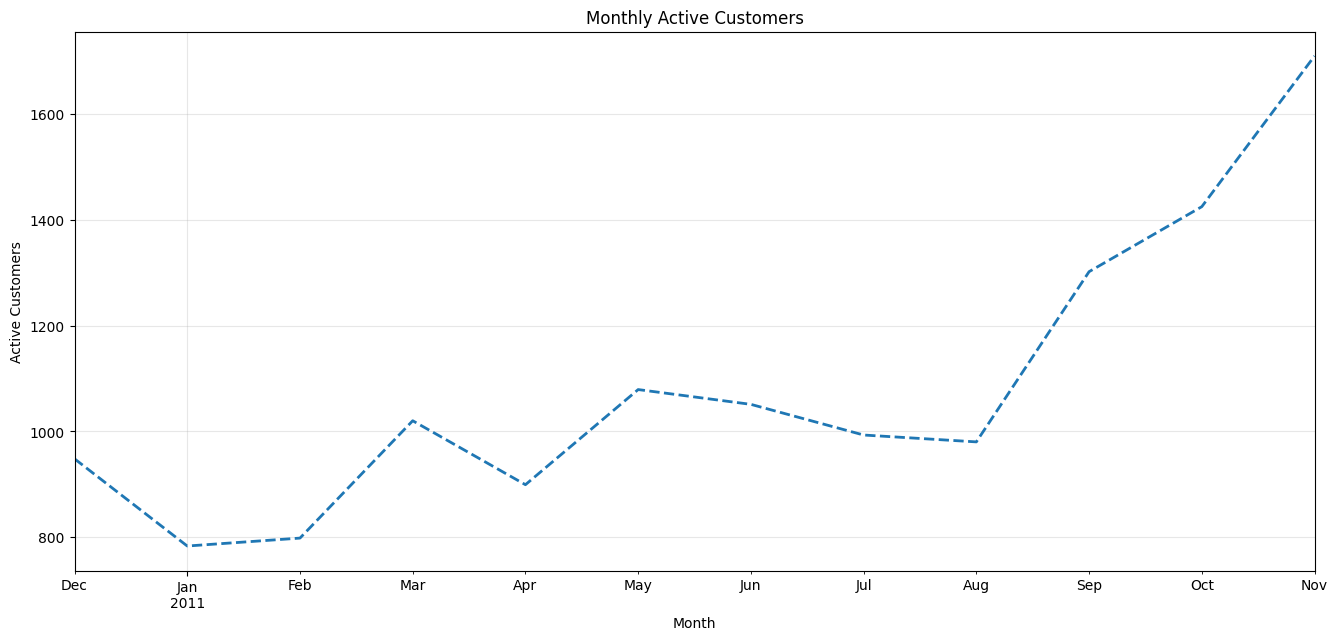

In [121]:
data["CustomerID"].resample("MS").nunique().plot(figsize=(16,7),ls="--",lw=2)

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.grid(alpha=0.3)

plt.show()


### 📌 Business Insight

- The number of active customers varies across different months.
- Higher customer activity reflects stronger customer engagement and business performance.
- Tracking active customers helps measure customer retention and acquisition over time.

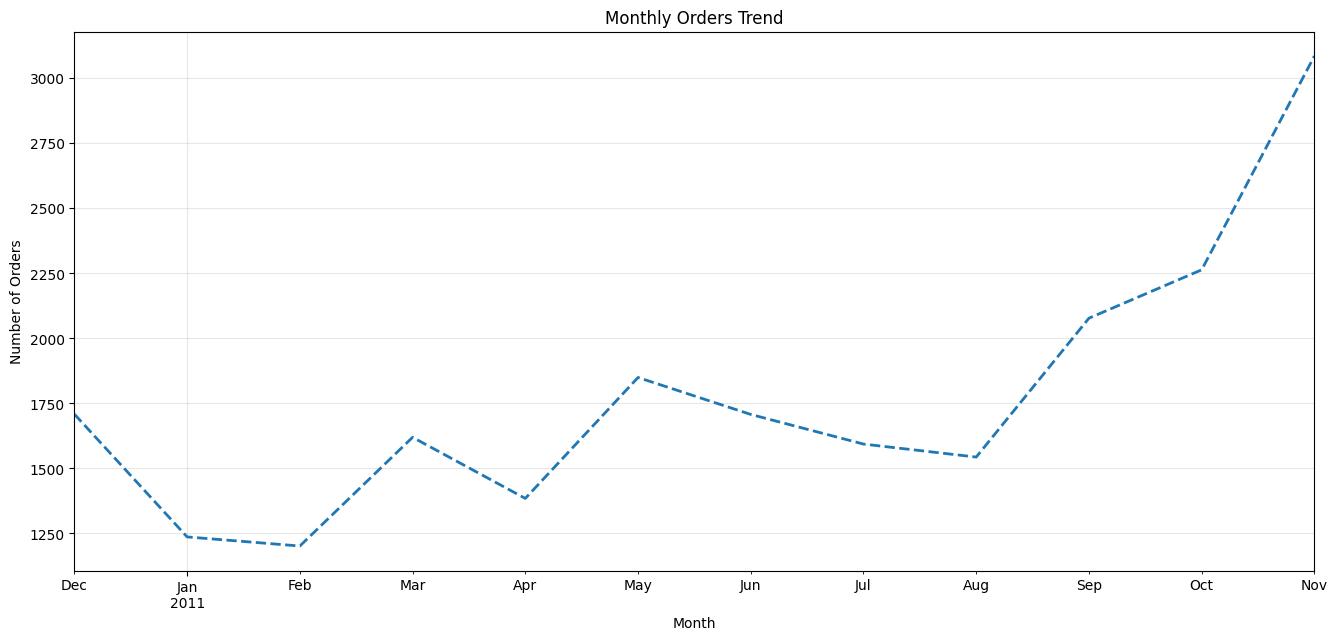

In [119]:
data["InvoiceNo"].resample("MS").nunique().plot(figsize=(16,7),ls="--",lw=2)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.3)
plt.show()

### 📌 Business Insight

- Monthly order volume changes throughout the year.
- Some months experience significantly higher order activity, indicating seasonal demand.
- Understanding these trends helps optimize inventory planning and promotional campaigns.

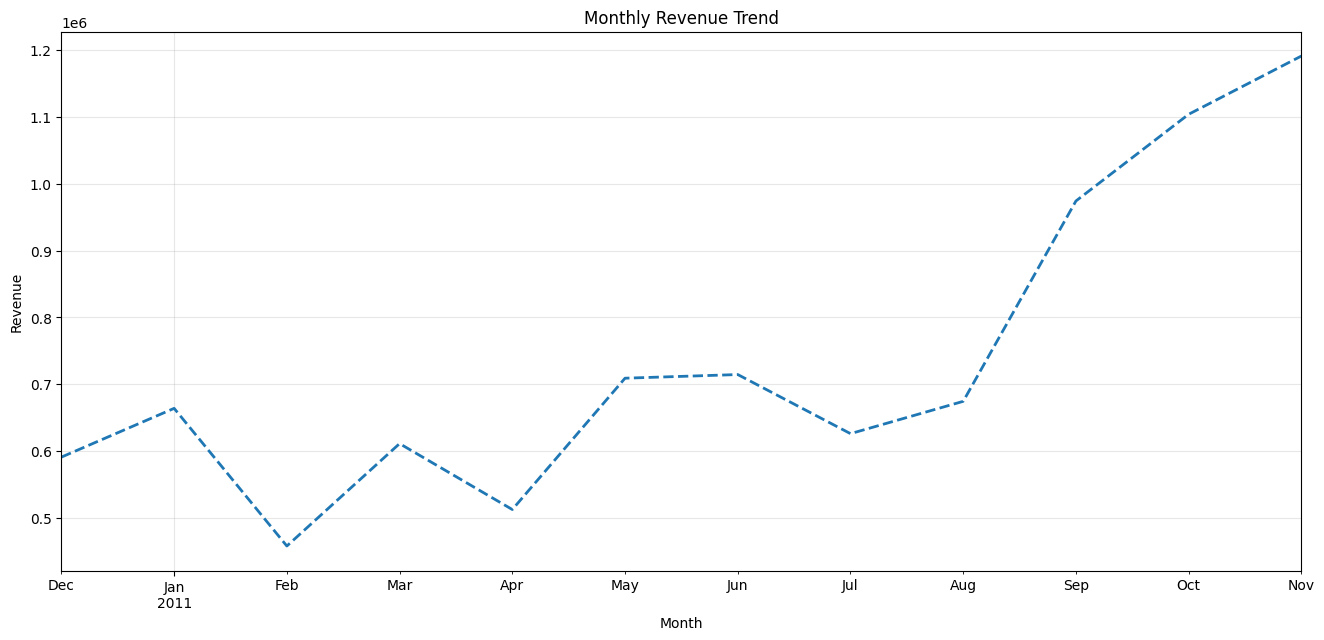

In [120]:
data["Total"].resample("MS").sum().plot(figsize=(16,7),ls="--",lw=2)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()

### 📌 Business Insight

- Monthly revenue fluctuates over time, reflecting changes in customer purchasing behavior.
- Revenue peaks indicate periods of strong sales performance.
- Monitoring revenue trends helps businesses forecast future sales and allocate resources efficiently.

# 🎯 RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) Analysis is a customer segmentation technique used to identify valuable customers based on their purchasing behavior.

### What does RFM mean?

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much money a customer spends.

By combining these three metrics, businesses can identify loyal customers, high-value customers, potential loyalists, and customers who are at risk of churning.

In [43]:
data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Total
InvoiceDate,,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
2011-11-30 17:39:00,C579886,22197,POPCORN HOLDER,1,0.85,15676.0,United Kingdom,0.85
2011-11-30 17:39:00,C579886,23146,TRIPLE HOOK ANTIQUE IVORY ROSE,1,3.29,15676.0,United Kingdom,3.29
2011-11-30 17:42:00,C579887,84946,ANTIQUE SILVER T-LIGHT GLASS,1,1.25,16717.0,United Kingdom,1.25


In [44]:
monetry = data.groupby("CustomerID")["Total"].sum()
monetry =monetry.reset_index()
monetry

,CustomerID,Total
0,12346.0,154367.20
1,12347.0,4085.18
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4325,18280.0,180.60
4326,18281.0,80.82
4327,18282.0,101.66
4328,18283.0,1886.88


## 💰 Monetary Analysis

The Monetary metric measures the total amount spent by each customer during the observation period.

It helps identify high-value customers who contribute the most revenue to the business.

In [45]:
frequency =data.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency


,CustomerID,InvoiceNo
0,12346.0,2
1,12347.0,6
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4325,18280.0,1
4326,18281.0,1
4327,18282.0,2
4328,18283.0,15


## 🔄 Frequency Analysis

Frequency measures how often a customer makes purchases.

Customers with higher purchase frequency are generally more loyal and engaged with the business.

## ⏰ Recency Analysis

Recency measures how recently a customer made their last purchase.

Customers who purchased more recently are generally more likely to purchase again compared to inactive customers.

In [46]:
maximum_date=data.index.max()

In [47]:
maximum_date=maximum_date + pd.DateOffset(days=1)
maximum_date

Timestamp('2011-12-01 17:42:00')

In [48]:
gap_in_days=maximum_date - data.index

In [ ]:
data["difference"]=gap_in_days.days

In [50]:
data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Total,difference
InvoiceDate,,,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,365
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,365
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,365
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,365
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,365
...,...,...,...,...,...,...,...,...,...
2011-11-30 17:39:00,C579886,22197,POPCORN HOLDER,1,0.85,15676.0,United Kingdom,0.85,1
2011-11-30 17:39:00,C579886,23146,TRIPLE HOOK ANTIQUE IVORY ROSE,1,3.29,15676.0,United Kingdom,3.29,1
2011-11-30 17:42:00,C579887,84946,ANTIQUE SILVER T-LIGHT GLASS,1,1.25,16717.0,United Kingdom,1.25,1


In [51]:
recency=data.groupby("CustomerID")["difference"].min().reset_index()

In [52]:
recency

,CustomerID,difference
0,12346.0,317
1,12347.0,31
2,12348.0,67
3,12349.0,10
4,12350.0,302
...,...,...
4325,18280.0,269
4326,18281.0,172
4327,18282.0,114
4328,18283.0,1


## 🔗 Building the RFM Dataset

The Recency, Frequency, and Monetary metrics are combined into a single dataset.

This unified RFM dataset forms the foundation for customer segmentation and behavioral analysis.

In [53]:
fm_data =pd.merge(frequency,monetry,on="CustomerID")

In [54]:
rfm_data= pd.merge(fm_data,recency,on="CustomerID")
rfm_data

,CustomerID,InvoiceNo,Total,difference
0,12346.0,2,154367.20,317
1,12347.0,6,4085.18,31
2,12348.0,4,1797.24,67
3,12349.0,1,1757.55,10
4,12350.0,1,334.40,302
...,...,...,...,...
4325,18280.0,1,180.60,269
4326,18281.0,1,80.82,172
4327,18282.0,2,101.66,114
4328,18283.0,15,1886.88,1


In [55]:
rfm_data.rename(columns={"Total":"monetry","InvoiceNo":"frequency","difference":"recency"},inplace=True)

In [56]:
rfm_data

,CustomerID,frequency,monetry,recency
0,12346.0,2,154367.20,317
1,12347.0,6,4085.18,31
2,12348.0,4,1797.24,67
3,12349.0,1,1757.55,10
4,12350.0,1,334.40,302
...,...,...,...,...
4325,18280.0,1,180.60,269
4326,18281.0,1,80.82,172
4327,18282.0,2,101.66,114
4328,18283.0,15,1886.88,1


## 📊 Understanding Monetary Distribution

Before assigning RFM scores, it is important to understand how customer spending is distributed.

This analysis helps identify spending patterns and detect potential outliers among customers.

In [57]:
rfm_data["monetry"].max()

np.float64(269195.0)

In [58]:
rfm_data["monetry"].median()

np.float64(659.6700000000001)

In [59]:
rfm_data["monetry"].describe()

count      4330.000000
mean       2039.000183
std        8944.277457
min           1.250000
25%         305.652500
50%         659.670000
75%        1627.037500
max      269195.000000
Name: monetry, dtype: float64

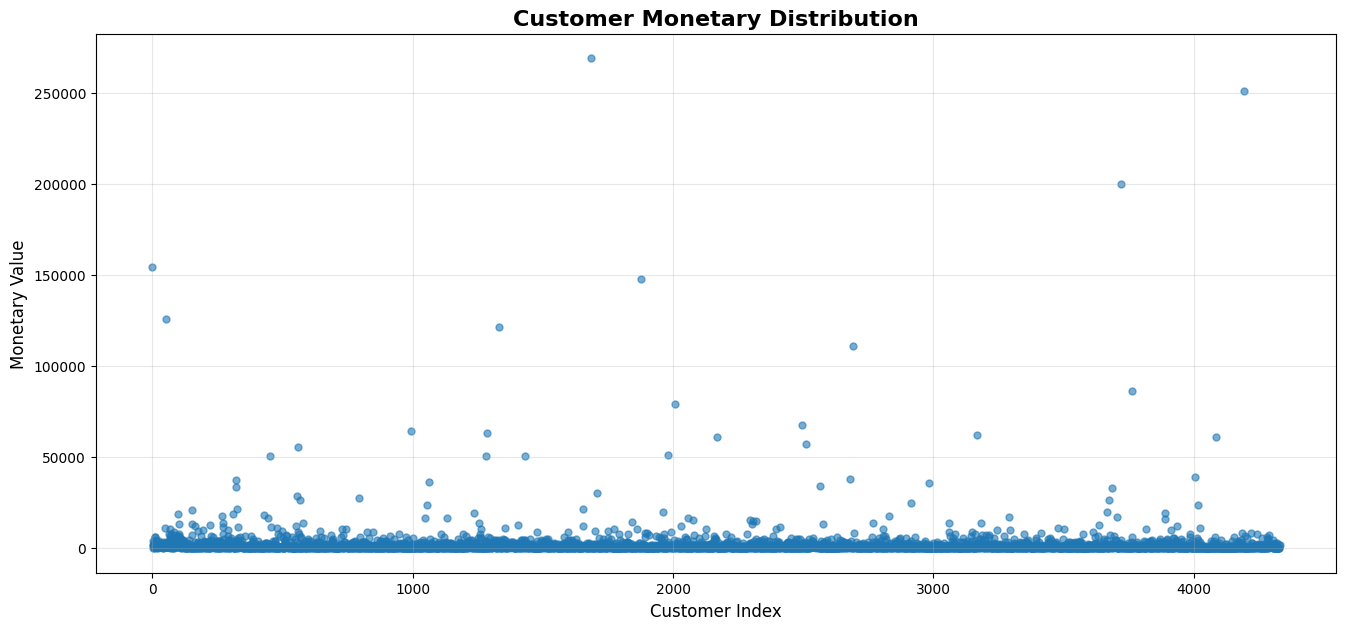

In [127]:
plt.figure(figsize=(16,7))

plt.scatter(
    rfm_data.index,
    rfm_data["monetry"],
    s=25,          # Point size
    alpha=0.6
)

plt.title("Customer Monetary Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Index", fontsize=12)
plt.ylabel("Monetary Value", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

### 📌 Business Insight

- The scatter plot shows the distribution of customer spending across all customers.
- Most customers contribute a relatively small amount of revenue, while a few customers generate significantly higher sales.
- This indicates the presence of high-value customers, making customer segmentation essential for targeted marketing strategies.

## 📐 Defining RFM Score Thresholds

To categorize customers effectively, the RFM metrics are divided into five score levels using quantile-based thresholds.

These thresholds ensure that customers are ranked relative to the overall distribution of Recency, Frequency, and Monetary values.

In [61]:
rfm_data["monetry"].quantile(0.20).round()
rfm_data["monetry"].quantile(0.40).round()
rfm_data["monetry"].quantile(0.60).round()
rfm_data["monetry"].quantile(0.80).round()

np.float64(2025.0)

## ⚙️ Creating Dynamic Bin Ranges

A reusable function is created to calculate quantile-based bin ranges automatically.

These bins will later be used to assign RFM scores to every customer.

In [ ]:
def get_bins_range(data):
    r20 = data.quantile(0.20).round()
    r40 = data.quantile(0.40).round()
    r60 = data.quantile(0.60).round()
    r80 = data.quantile(0.80).round()

    return [0,r20,r40,r60,r80,float("inf")]

In [63]:
get_bins_range(rfm_data["monetry"])

[0,
 np.float64(245.0),
 np.float64(485.0),
 np.float64(931.0),
 np.float64(2025.0),
 inf]

In [64]:
get_bins_range(rfm_data["frequency"])

[0, np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(6.0), inf]

In [65]:
grp=get_bins_range(rfm_data["recency"])
grp

[0,
 np.float64(13.0),
 np.float64(31.0),
 np.float64(69.0),
 np.float64(178.0),
 inf]

## 🎯 Assigning RFM Scores

Each customer receives a score between 1 and 5 for Recency, Frequency, and Monetary.

Higher scores represent more valuable customer behavior.

In [66]:
def calculate_score(data,labels):
    grp= get_bins_range(data)
    score = pd.cut(data,bins=grp,labels=labels)
    return score 

In [67]:
rfm_data["M_Score"]=calculate_score(rfm_data["monetry"],[1,2,3,4,5])

In [68]:
rfm_data

,CustomerID,frequency,monetry,recency,M_Score
0,12346.0,2,154367.20,317,5
1,12347.0,6,4085.18,31,5
2,12348.0,4,1797.24,67,4
3,12349.0,1,1757.55,10,4
4,12350.0,1,334.40,302,2
...,...,...,...,...,...
4325,18280.0,1,180.60,269,1
4326,18281.0,1,80.82,172,1
4327,18282.0,2,101.66,114,1
4328,18283.0,15,1886.88,1,4


In [69]:
rfm_data["F_Score"]=calculate_score(rfm_data["frequency"],[1,2,3,4,5])

In [70]:
rfm_data

,CustomerID,frequency,monetry,recency,M_Score,F_Score
0,12346.0,2,154367.20,317,5,2
1,12347.0,6,4085.18,31,5,4
2,12348.0,4,1797.24,67,4,4
3,12349.0,1,1757.55,10,4,1
4,12350.0,1,334.40,302,2,1
...,...,...,...,...,...,...
4325,18280.0,1,180.60,269,1,1
4326,18281.0,1,80.82,172,1,1
4327,18282.0,2,101.66,114,1,2
4328,18283.0,15,1886.88,1,4,5


In [71]:
rfm_data["R_Score"]=calculate_score(rfm_data["recency"],[5,4,3,2,1])

In [72]:
rfm_data

,CustomerID,frequency,monetry,recency,M_Score,F_Score,R_Score
0,12346.0,2,154367.20,317,5,2,1
1,12347.0,6,4085.18,31,5,4,4
2,12348.0,4,1797.24,67,4,4,3
3,12349.0,1,1757.55,10,4,1,5
4,12350.0,1,334.40,302,2,1,1
...,...,...,...,...,...,...,...
4325,18280.0,1,180.60,269,1,1,1
4326,18281.0,1,80.82,172,1,1,2
4327,18282.0,2,101.66,114,1,2,2
4328,18283.0,15,1886.88,1,4,5,5


## 👥 Customer Segmentation

Based on the RFM scores, customers are classified into meaningful business segments such as:

- 💎 VIP Customers
- 💰 High Paying Customers
- ❤️ Loyal Customers
- 🌱 New Customers
- ⚠️ At Risk Customers
- ❌ Lost Customers

These categories help businesses design targeted marketing and retention strategies.

In [73]:
def get_customer_category(row):
    r =row["R_Score"]
    m = row["M_Score"]
    f = row["F_Score"]
    if m==5:
        return "High Paying"
    elif r >= 4 and f>=4 and m>=4:
        return "VIP"
    elif r>=3 and m>=3:
        return "Loyal"
    elif r<=2 and f>=3:
        return "At Risk"
    elif r>=3 and f<=2:
        return "New Customer"
    else:
        return "Lost"

In [74]:
rfm_data["customer_category"]=rfm_data.apply(get_customer_category,axis=1)

In [75]:
rfm_data["customer_category"].value_counts()

customer_category
Lost            1299
High Paying      866
Loyal            803
New Customer     635
At Risk          395
VIP              332
Name: count, dtype: int64

In [76]:
import seaborn as sns

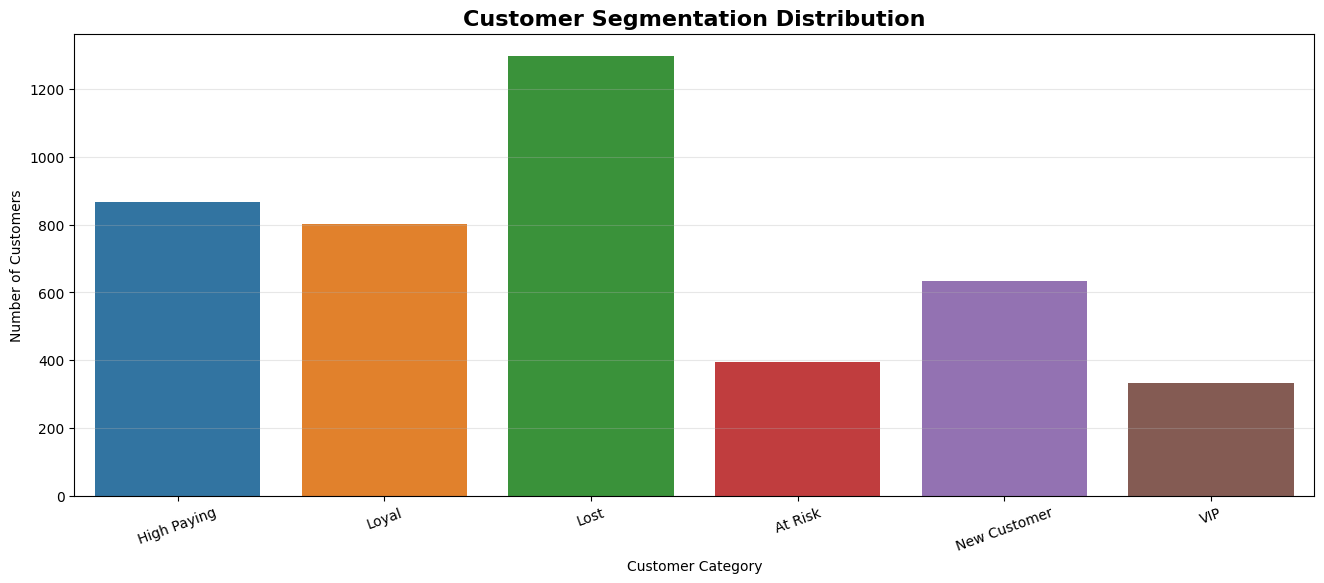

In [128]:
plt.figure(figsize=(16,6))

sns.countplot(
    data=rfm_data,
    x="customer_category",
    hue="customer_category"
)

plt.title("Customer Segmentation Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.show()

### 📌 Business Insight

- The visualization shows how customers are distributed across different RFM segments.
- High Paying and VIP customers contribute significant business value and should be retained through loyalty programs.
- At Risk and Lost customers require targeted retention campaigns to reduce customer churn.
- New Customers present opportunities for personalized onboarding and future engagement.